<a href="https://colab.research.google.com/github/MinThuKhant763/machine-learning/blob/main/Linear_Regression_Using_Standard_Scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('/content/Admission_Predict.csv')
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [19]:
df.tail()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67
399,400,333,117,4,5.0,4.0,9.66,1,0.95


In [20]:
df.drop("Serial No.",axis=1,inplace=True)
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [22]:
y = df["Chance of Admit "]
df.drop("Chance of Admit ",axis=1,inplace=True)
print(y.head())

0    0.92
1    0.76
2    0.72
3    0.80
4    0.65
Name: Chance of Admit , dtype: float64


In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df,y,test_size=0.2,random_state=42)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test,pred))
print("Root Mean Squared Error : ",rmse)

Root Mean Squared Error :  0.06794853476922813


In [26]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(df)
df_std = sc.fit_transform(df)
print(df)
print(df_std)

     GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  Research
0          337          118                  4  4.5   4.5  9.65         1
1          324          107                  4  4.0   4.5  8.87         1
2          316          104                  3  3.0   3.5  8.00         1
3          322          110                  3  3.5   2.5  8.67         1
4          314          103                  2  2.0   3.0  8.21         0
..         ...          ...                ...  ...   ...   ...       ...
395        324          110                  3  3.5   3.5  9.04         1
396        325          107                  3  3.0   3.5  9.11         1
397        330          116                  4  5.0   4.5  9.45         1
398        312          103                  3  3.5   4.0  8.78         0
399        333          117                  4  5.0   4.0  9.66         1

[400 rows x 7 columns]
[[ 1.76210664  1.74697064  0.79882862 ...  1.16732114  1.76481828
   0.90911166]
 [ 0.62

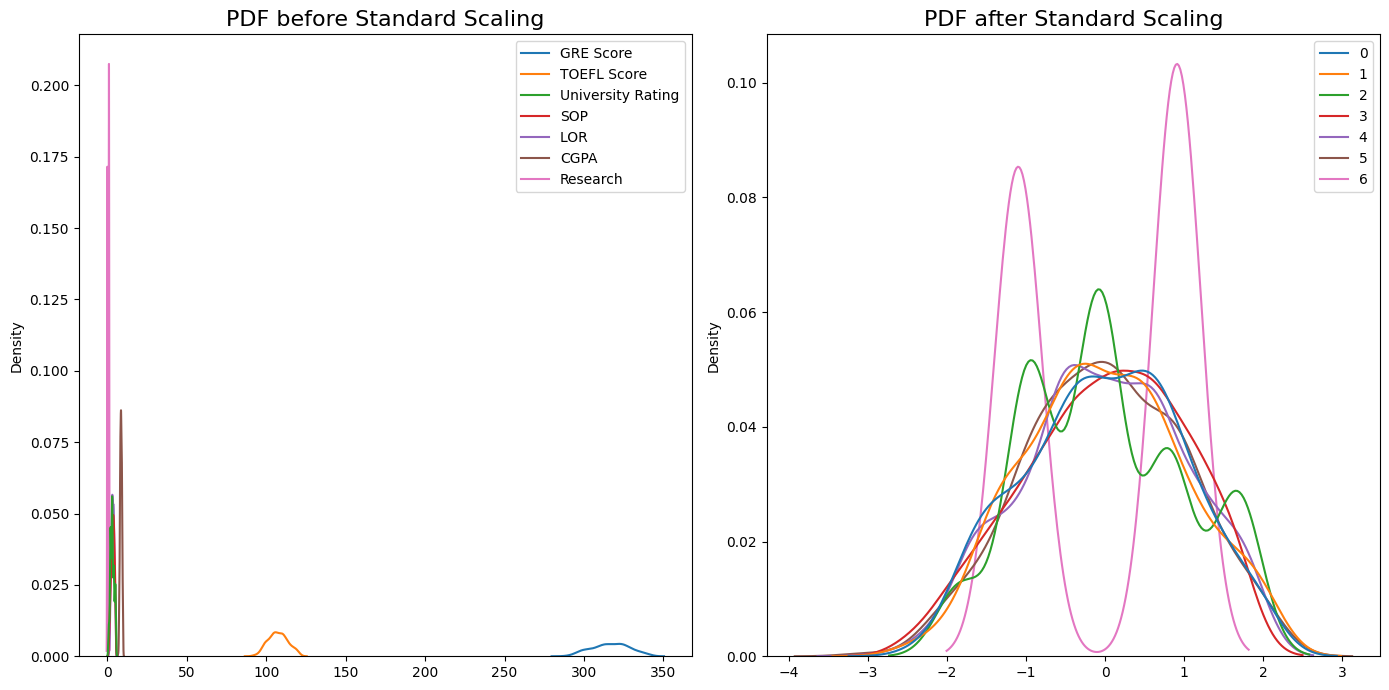

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(14,7))
plt.subplot(1,2,1)
plt.title("PDF before Standard Scaling",fontsize=16)
sns.kdeplot(data=df,color="blue")
plt.subplot(1,2,2)
plt.title("PDF after Standard Scaling",fontsize=16)
sns.kdeplot(data=df_std,color="red")
plt.tight_layout()
plt.show()

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df_std,y,test_size=0.2,random_state=42)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test,pred))
print("Root Mean Squared Error (using Standard Scaling)",rmse)


Root Mean Squared Error (using Standard Scaling) 0.06794853476922817
